In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Iris dataset loaded successfully.")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Iris dataset loaded successfully.
Training data shape: (105, 4)
Testing data shape: (45, 4)


### 2. Build a Random Forest Classifier with Default `n_estimators` (10)

First, let's train a Random Forest classifier using the default number of trees, which is 10, and measure its prediction accuracy.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the Random Forest Classifier with default n_estimators (10)
rf_classifier_default = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier_default.fit(X_train, y_train)

# Make predictions on the test set
y_pred_default = rf_classifier_default.predict(X_test)

# Calculate the accuracy score
accuracy_default = accuracy_score(y_test, y_pred_default)

print(f"Random Forest Classifier with default n_estimators (10) accuracy: {accuracy_default:.4f}")

Random Forest Classifier with default n_estimators (10) accuracy: 1.0000


### 3. Fine-tune `n_estimators` and Identify the Best Score

Now, let's explore different values for `n_estimators` (number of trees) to see if we can improve the model's performance. We'll test a range of values and identify the one that yields the highest accuracy.

Best accuracy score: 1.0000 with n_estimators = 1


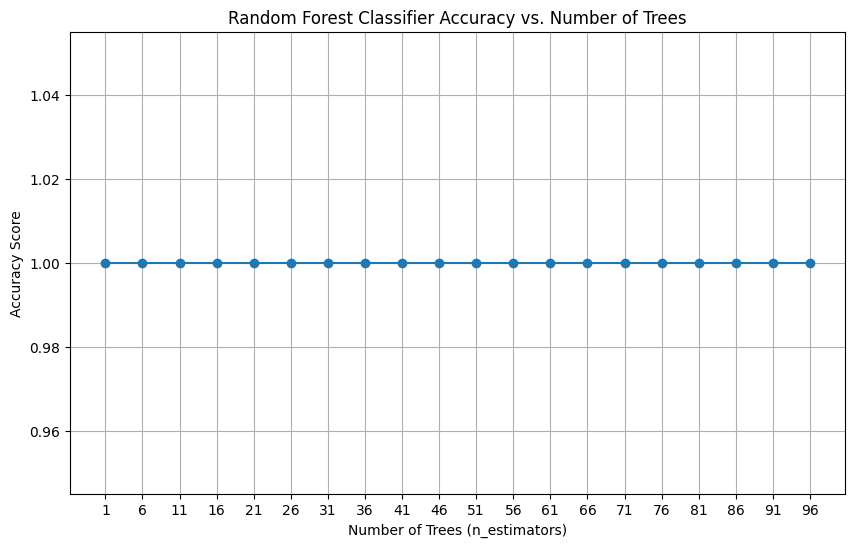

In [6]:
import matplotlib.pyplot as plt
import numpy as np

n_estimators_range = np.arange(1, 101, 5) # Test n_estimators from 1 to 100 with a step of 5
scores = []

best_score = 0
best_n_estimators = 0

for n in n_estimators_range:
    rf_classifier = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_classifier.fit(X_train, y_train)
    y_pred = rf_classifier.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

    if score > best_score:
        best_score = score
        best_n_estimators = n

print(f"Best accuracy score: {best_score:.4f} with n_estimators = {best_n_estimators}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, scores, marker='o', linestyle='-')
plt.title('Random Forest Classifier Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.xticks(n_estimators_range)
plt.grid(True)
plt.show()